# Chapter 5: Model Evaluation and Improvement

We will focus on supervised models (regression & classification) as evaluating unsupervised learning is often a very qualitative process

In this chapter, we will go over **cross-validation**, a robust way to assess generalization performance, and other methods such as **grid search**

In [58]:
# create an environment where we can import all the needed modules
import sys, os
sys.path.append('../introduction_to_ml_with_python')
os.environ["PATH"] += os.pathsep + "/opt/homebrew/bin"
import mglearn

In [2]:
# just to illustrate what we have been doing so far
from sklearn.datasets import make_blobs
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

x, y = make_blobs(random_state=0)
xtrain, xtest, ytrain, ytest = train_test_split(x, y, random_state=0)
logreg = LogisticRegression().fit(xtrain, ytrain)
print("Test set score: {:.2f}".format(logreg.score(xtest, ytest)))

Test set score: 0.88


## Cross-Validation

**Cross-validation** is a statistical method of evaluating generalization performance that is more stable and thorough than using a split into a training and test set. In this approach, the data is instead split repeatedly and multiple modles are trained.

The most commonly used version of cross-validation is **k-fold cross-validation**, where the data is first partitioned into *k* parts of (approximately) equal size called *folds*. Next, a sequence of models is trained. The first model is trained using the first fold as the test set, and the remaining folds are used as the training set. Another model is then built, setting the second fold as the test while the rest remain as the training set, and the process continues on.

In [3]:
# practice cross-validation
from sklearn.model_selection import cross_val_score
from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression

iris   = load_iris()
logreg = LogisticRegression()
scores = cross_val_score(logreg, iris.data, iris.target) # default is 5 splits
print(scores)

[0.96666667 1.         0.93333333 0.96666667 1.        ]


/Users/giovannimadrigal/opt/anaconda3/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:444: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [4]:
# do 3 splits
scores = cross_val_score(logreg, iris.data, iris.target, cv=3)
print(scores)

[0.98 0.96 0.98]


/Users/giovannimadrigal/opt/anaconda3/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:444: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [5]:
# A common way to summarize the accuracy is by computing the mean
print(scores.mean())

0.9733333333333333


There are several benefits to using cross-validation instead of a single split. First, splitting is done at random. Imagine that we get "lucky" when randomly splitting, and all hard examples are in the training set. In that case, the test will only contain "easy" examples. Conversely, if we are "unlucky" we might have randomly put all the hard examples in the test set and all the easy examples in the training set.

Having multiple splits of the data also provides some information about how senstive our model is to the selection of the training dataset. Also, more folds means using $\frac{N-1}{N}$ as training and $\frac{1}{N}$ as test sets.

In [6]:
#
# splitting the data into k folds is not always a good idea
#
print(iris.target) # see how the data is not randomly distributed

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]


## Stratified k-Fold Cross-Validation and Other Strategies
In **stratified k-fold cross validation**, we split the data such that the proportions between the classes are the same in each fold as they are in the whole dataset

We can also control the parameters of the splitting ourselves

In [7]:
from sklearn.model_selection import KFold

kFold = KFold(n_splits=5)
print(cross_val_score(logreg, iris.data, iris.target, cv = kFold))

kFold = KFold(n_splits=3)
print(cross_val_score(logreg, iris.data, iris.target, cv = kFold))

[1.         1.         0.86666667 0.93333333 0.83333333]
[0. 0. 0.]


/Users/giovannimadrigal/opt/anaconda3/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:444: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Users/giovannimadrigal/opt/anaconda3/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:444: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/l

In [8]:
# we may need to shuffle the points around
kFold = KFold(n_splits=3, shuffle=True, random_state=0)
print(cross_val_score(logreg, iris.data, iris.target, cv = kFold))

[0.98 0.96 0.96]


/Users/giovannimadrigal/opt/anaconda3/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:444: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Users/giovannimadrigal/opt/anaconda3/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:444: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/l

Another approach is to use the **leave-one-out** approach, where each fold is a single sample. So instead of folds representing sections of data, each fold is a data point.

In [9]:
from sklearn.model_selection import LeaveOneOut

loo    = LeaveOneOut()
scores = cross_val_score(logreg, iris.data, iris.target, cv=loo)
print("Number of iterations:", len(scores), "and mean", scores.mean())

/Users/giovannimadrigal/opt/anaconda3/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:444: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Users/giovannimadrigal/opt/anaconda3/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:444: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/l

Number of iterations: 150 and mean 0.9666666666666667


/Users/giovannimadrigal/opt/anaconda3/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:444: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Users/giovannimadrigal/opt/anaconda3/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:444: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/l

In **shuffle-split**, each split samples *train size* many points for training sets and *test size* points for test sets. It is repeated *n* times

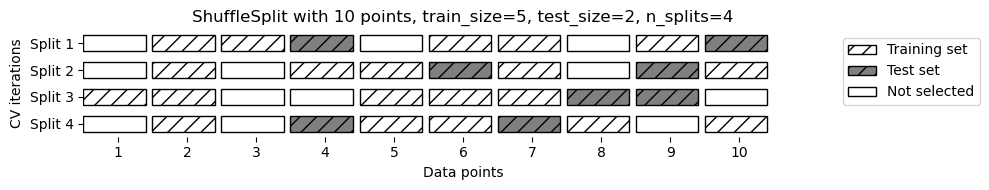

In [10]:
mglearn.plots.plot_shuffle_split()

In [11]:
from sklearn.model_selection import ShuffleSplit

shuffle_split = ShuffleSplit(test_size=.5, train_size=.5, n_splits=10)
scores        = cross_val_score(logreg, iris.data, iris.target, cv = shuffle_split)
print(scores)

[0.97333333 0.96       0.96       0.96       0.97333333 0.96
 1.         0.93333333 0.94666667 0.96      ]


/Users/giovannimadrigal/opt/anaconda3/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:444: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Users/giovannimadrigal/opt/anaconda3/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:444: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/l

We can also stratify/split using *groups*.

In [12]:
from sklearn.model_selection import GroupKFold

x, y   = make_blobs(n_samples=12, random_state=0)
groups = [0, 0, 0, 1, 1, 1, 1, 2, 2, 3, 3, 3] # since we have 3 per group
scores = cross_val_score(logreg, x, y, groups=groups, cv = GroupKFold(n_splits=3))
print(scores)

[0.75       0.6        0.66666667]


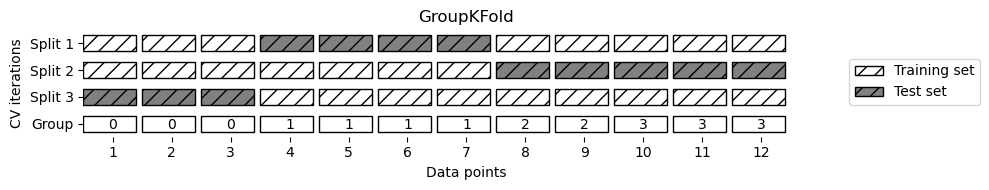

In [13]:
# visualize
mglearn.plots.plot_group_kfold()

## Grid Search

Finding the values of the important parameters of a model (the ones that provide the best generalization performance) is a tricky task, but necessary for almost all models and datasets. *Grid search* basically means trying all possible combinations of parameters of interest

In [14]:
#
# illustrate what this would look like if
# done manually
#

from sklearn.svm import SVC

xtrain, xtest, ytrain, ytest = train_test_split(iris.data, iris.target, random_state=0)

print("Size of training set: {} size of test set: {}".format(xtrain.shape[0], xtest.shape[0]))
best_score      = 0
best_parameters = {}

for gamma in [0.001, 0.01, 0.1, 1, 10, 100]:
    for c in [0.001, 0.01, 0.1, 1, 10, 100]:
    # for each combination of parameters, train an SVC
        svm = SVC(gamma=gamma, C=c)
        svm.fit(xtrain, ytrain)
        # evaluate the SVC on the test set
        score = svm.score(xtest, ytest)
        # if we got a better score, store the score and parameters
        if score > best_score:
            best_score = score
            best_parameters = {'C': c, 'gamma': gamma}

print("Best score: {:.2f}".format(best_score))
print("Best parameters: {}".format(best_parameters))

Size of training set: 112 size of test set: 38
Best score: 0.97
Best parameters: {'C': 100, 'gamma': 0.001}


The approach implemented above is wrong and bad. We used the test data set to adjust the parameters of the model and not the train dataset.

One way to resolve this problem is to split the data again, so we have three data sets: the training set to build the model, the validation (or development) set to select the parameters of the model, and the test set to evaluate the performance of the selected parameters

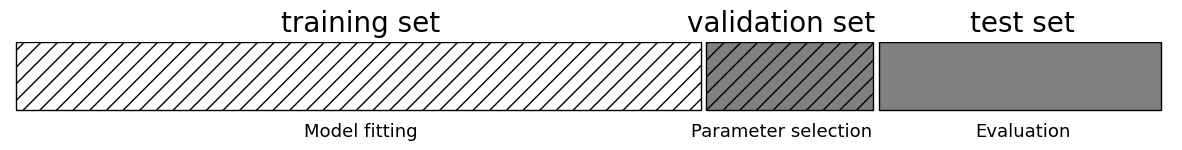

In [15]:
mglearn.plots.plot_threefold_split()

In [16]:
# do a normal split
xtrainval, Xtest, ytrainval, ytest = train_test_split(iris.data, iris.target, random_state=0)

# do a secondary split
xtrain, xvalid, ytrain, yvalid = train_test_split(xtrainval, ytrainval, random_state=1)

print("Size of training set: {} size of validation set: {} size of test set:"" {}\n".format(xtrain.shape[0], xvalid.shape[0], xtest.shape[0]))

best_score      = 0
best_parameters = {}

for gamma in [0.001, 0.01, 0.1, 1, 10, 100]:
    for c in [0.001, 0.01, 0.1, 1, 10, 100]:
        # for each combination of parameters, train an SVC
        svm = SVC(gamma=gamma, C=c)
        svm.fit(xtrain, ytrain)
        # evaluate the SVC on the test set
        score = svm.score(xvalid, yvalid)
        # if we got a better score, store the score and parameters
        if score > best_score:
            best_score = score
            best_parameters = {'C': c, 'gamma': gamma}

# rebuild a model on the combined training and validation set,
# and evaluate it on the test set
svm = SVC(**best_parameters)
svm.fit(xtrainval, ytrainval)
test_score = svm.score(xtest, ytest)
print("Best score on validation set: {:.2f}".format(best_score))
print("Best parameters: ", best_parameters)
print("Test set score with best parameters: {:.2f}".format(test_score))

Size of training set: 84 size of validation set: 28 size of test set: 38

Best score on validation set: 0.96
Best parameters:  {'C': 10, 'gamma': 0.001}
Test set score with best parameters: 0.92


What we did was prevent the test set from "leaking" information to the model to improve its accuracy

In [20]:
#
# GRID SEARCH WITH CROSS-VALIDATION
import numpy as np

for gamma in [0.001, 0.01, 0.1, 1, 10, 100]:
    for c in [0.001, 0.01, 0.1, 1, 10, 100]:
        # for each combination of parameters,
        # train an SVC
        svm = SVC(gamma=gamma, C=c)
        # perform cross-validation
        scores = cross_val_score(svm, xtrainval, ytrainval, cv=5)
        # compute mean cross-validation accuracy
        score = np.mean(scores)
        # if we got a better score, store the score and parameters
        if score > best_score:
            best_score = score
            best_parameters = {'C': c, 'gamma': gamma}
# rebuild a model on the combined training and validation set
svm = SVC(**best_parameters)
svm.fit(xtrainval, ytrainval)


SVC(C=10, gamma=0.1)

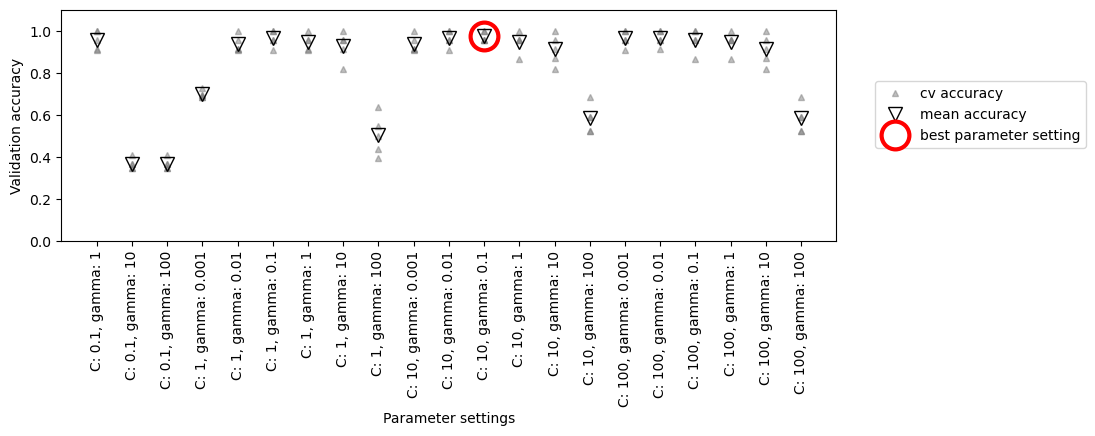

In [24]:
# illustrate our model selected
mglearn.plots.plot_cross_val_selection()

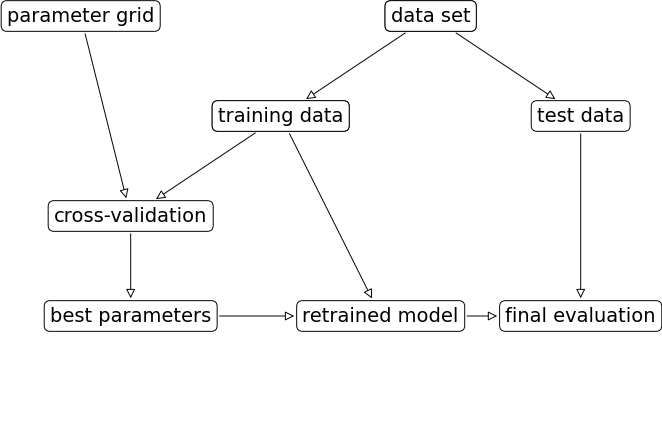

In [21]:
# illustrate what we did above
mglearn.plots.plot_grid_search_overview()

In [ ]:
# using the grid search utility
from sklearn.model_selection import GridSearchCV

#
# construct a dict
# of parameter -> list of values
#
param_grid  = {'C': [0.001, 0.01, 0.1, 1, 10, 100],
               'gamma': [0.001, 0.01, 0.1, 1, 10, 100]}

grid_search = GridSearchCV(SVC(), param_grid=param_grid, cv=5)

xtrain, xtest, ytrain, ytest = train_test_split(iris.data, iris.target, random_state=0)

# it will run cross validation of 5 splits
grid_search.fit(xtrain, ytrain) 

# will end up fitting with the best model
grid_search.score(xtest, ytest)


# this is better because we DID NOT use the test set to just the model

0.9736842105263158

In [26]:
# access the best models parameters
print(grid_search.best_params_, grid_search.best_score_)

{'C': 10, 'gamma': 0.1} 0.9731225296442687


In [28]:
# look at the coefficients
print(grid_search.best_estimator_)

SVC(C=10, gamma=0.1)


In [29]:
# let's look at how the different parameters faired in the grid search
import pandas as pd

results = pd.DataFrame(grid_search.cv_results_)
display(results.head())

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_C,param_gamma,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.000549,0.000092,0.000270,0.000034,0.001,0.001,"{'C': 0.001, 'gamma': 0.001}",0.347826,0.347826,0.363636,0.363636,0.409091,0.366403,0.022485,22
1,0.000482,0.000065,0.000312,0.000159,0.001,0.01,"{'C': 0.001, 'gamma': 0.01}",0.347826,0.347826,0.363636,0.363636,0.409091,0.366403,0.022485,22
2,0.000453,0.000072,0.000453,0.000452,0.001,0.1,"{'C': 0.001, 'gamma': 0.1}",0.347826,0.347826,0.363636,0.363636,0.409091,0.366403,0.022485,22
3,0.000493,0.000047,0.000246,0.000016,0.001,1,"{'C': 0.001, 'gamma': 1}",0.347826,0.347826,0.363636,0.363636,0.409091,0.366403,0.022485,22
4,0.000528,0.000086,0.000258,0.000038,0.001,10,"{'C': 0.001, 'gamma': 10}",0.347826,0.347826,0.363636,0.363636,0.409091,0.366403,0.022485,22


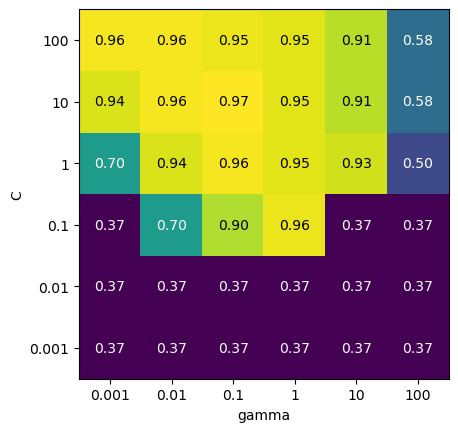

In [30]:
# see the scores
scores = np.array(results.mean_test_score).reshape(6, 6)

# plot the mean cross-validation scores
mglearn.tools.heatmap(scores, xlabel='gamma', xticklabels=param_grid['gamma'], ylabel='C', yticklabels=param_grid['C'], cmap="viridis")

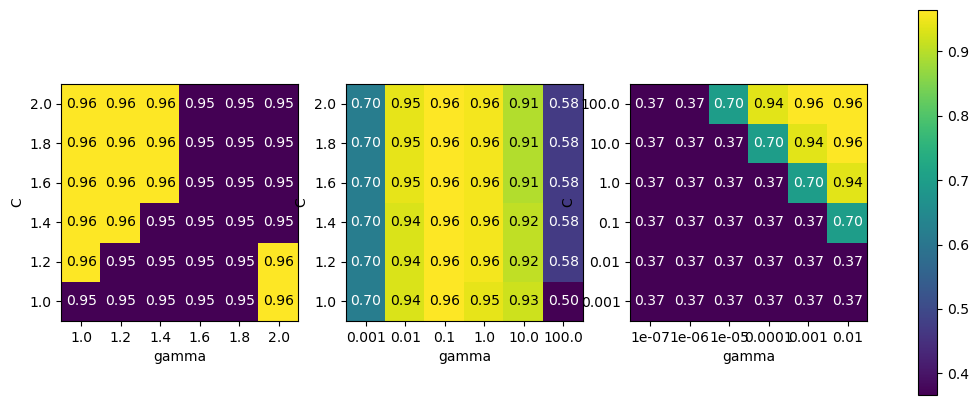

In [31]:
# visualize what it looks like to not choose parameter values wisely
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(13, 5))

param_grid_linear = {'C': np.linspace(1, 2, 6), 'gamma': np.linspace(1, 2, 6)}
param_grid_one_log = {'C': np.linspace(1, 2, 6), 'gamma': np.logspace(-3, 2, 6)}
param_grid_range = {'C': np.logspace(-3, 2, 6), 'gamma': np.logspace(-7, -2, 6)}

for param_grid, ax in zip([param_grid_linear, param_grid_one_log, param_grid_range], axes):
    grid_search = GridSearchCV(SVC(), param_grid, cv=5)
    grid_search.fit(xtrain, ytrain)
    scores = grid_search.cv_results_['mean_test_score'].reshape(6, 6)
    # plot the mean cross-validation scores
    scores_image = mglearn.tools.heatmap(scores, xlabel='gamma', ylabel='C', xticklabels=param_grid['gamma'], yticklabels=param_grid['C'], cmap="viridis", ax=ax)

plt.colorbar(scores_image, ax=axes.tolist())

In [32]:
# you can also feed this utility different sets of parameter combinations to try
# i.e., multiple dictionaries which can be used with different models

param_grid = [{'kernel': ['rbf'], 'C': [0.001, 0.01, 0.1, 1, 10, 100], 'gamma': [0.001, 0.01, 0.1, 1, 10, 100]},
              {'kernel': ['linear'], 'C': [0.001, 0.01, 0.1, 1, 10, 100]}]

grid_search = GridSearchCV(SVC(), param_grid, cv=5)
grid_search.fit(xtrain, ytrain)
print("Best parameters: {}".format(grid_search.best_params_))
print("Best cross-validation score: {:.2f}".format(grid_search.best_score_))

Best parameters: {'C': 10, 'gamma': 0.1, 'kernel': 'rbf'}
Best cross-validation score: 0.97


In [33]:
results = pd.DataFrame(grid_search.cv_results_)
display(results.head())

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_C,param_gamma,param_kernel,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.000766,0.000194,0.000521,0.000325,0.001,0.001,rbf,"{'C': 0.001, 'gamma': 0.001, 'kernel': 'rbf'}",0.347826,0.347826,0.363636,0.363636,0.409091,0.366403,0.022485,27
1,0.000606,0.000143,0.000294,0.000063,0.001,0.01,rbf,"{'C': 0.001, 'gamma': 0.01, 'kernel': 'rbf'}",0.347826,0.347826,0.363636,0.363636,0.409091,0.366403,0.022485,27
2,0.000420,0.000037,0.000263,0.000095,0.001,0.1,rbf,"{'C': 0.001, 'gamma': 0.1, 'kernel': 'rbf'}",0.347826,0.347826,0.363636,0.363636,0.409091,0.366403,0.022485,27
3,0.000528,0.000055,0.000318,0.000123,0.001,1,rbf,"{'C': 0.001, 'gamma': 1, 'kernel': 'rbf'}",0.347826,0.347826,0.363636,0.363636,0.409091,0.366403,0.022485,27
4,0.000508,0.000045,0.000262,0.000046,0.001,10,rbf,"{'C': 0.001, 'gamma': 10, 'kernel': 'rbf'}",0.347826,0.347826,0.363636,0.363636,0.409091,0.366403,0.022485,27


A *nested cross-validation* approach uses an outer loop to test the best model selected from an inner loop that is conducting a gridSearch approach. Thus, they report how well a model generalizes instead of reporting the best model or parameters used.

In [34]:
scores = cross_val_score(GridSearchCV(SVC(), param_grid, cv=5), iris.data, iris.target, cv=5)
print(scores)
print(scores.mean())

[0.96666667 1.         0.9        0.96666667 1.        ]
0.9666666666666668


In [39]:
# visualize what the nested grid search is actually doing
def nested_cv(x, y, inner_cv, outer_cv, Classifier, parameter_grid):
    outer_scores = []
    # for each split of the data in the outer cross-validation
    # (split method returns indices)
    for training_samples, test_samples in outer_cv.split(x, y):
        # find best parameter using inner cross-validation
        best_params = {}
        best_score  = -np.inf
        # iterate over parameters
        for parameters in parameter_grid:
            # accumulate score over inner splits
            cv_scores = []
            # iterate over inner cross-validation
            for inner_train, inner_test in inner_cv.split(x[training_samples], y[training_samples]):
                # build classifier given parameters and training data
                clf = Classifier(**parameters)
                clf.fit(x[inner_train], y[inner_train])
                # evaluate on inner test set
                score = clf.score(x[inner_test], y[inner_test])
                cv_scores.append(score)
            # compute mean score over inner folds
            mean_score = np.mean(cv_scores)
            if mean_score > best_score:
                # if better than so far, remember parameters
                best_score = mean_score
                best_params = parameters
        # build classifier on best parameters using outer training set
        clf = Classifier(**best_params)
        clf.fit(x[training_samples], y[training_samples])
        # evaluate
        outer_scores.append(clf.score(x[test_samples], y[test_samples]))
    return np.array(outer_scores)


In [40]:
from sklearn.model_selection import ParameterGrid, StratifiedKFold

scores = nested_cv(iris.data, iris.target, StratifiedKFold(5), StratifiedKFold(5), SVC, ParameterGrid(param_grid))
print("Cross-validation scores: {}".format(scores))

Cross-validation scores: [0.96666667 1.         0.96666667 0.96666667 1.        ]


Imbalanced datasets are normal in real world applications. But even high accuracy can be offset by a very imbalanced dataset. For example, if the model is 99% accurate but in 100 points, there is only 1 positive element, the model can easily miss it.

In [ ]:
from sklearn.datasets import load_digits
from sklearn.dummy import DummyClassifier 


digits = load_digits()
y      = digits.target == 9

#
# dummy classifier will always predict the majority class
#

xtrain, xtest, ytrain, ytest = train_test_split(digits.data, y, random_state=0)
dummy_majority               = DummyClassifier(strategy="most_frequent").fit(xtrain, ytrain)
pred_most_frequent           = dummy_majority.predict(xtest)
print(np.unique(pred_most_frequent))
print(dummy_majority.score(xtest, ytest)) # ~90% accurate without learning anything

[False]
0.8955555555555555


In [ ]:
from sklearn.tree import DecisionTreeClassifier

tree      = DecisionTreeClassifier(max_depth=2).fit(xtrain, ytrain)
pred_tree = tree.predict(xtest)
print(tree.score(xtest, ytest)) # this is roughly equal to our dummy model


0.9177777777777778


In [44]:
# let's try two different models to see if its the models or something else
from sklearn.linear_model import LogisticRegression

dummy      = DummyClassifier().fit(xtrain, ytrain) # default model -> random predictions
pred_dummy = dummy.predict(xtest)
print("Dummy score:", dummy.score(xtest, ytest))

logreg      = LogisticRegression(C=0.1).fit(xtrain, ytrain)
pred_logreg = logreg.predict(xtest)
print("Log score:", logreg.score(xtest, ytest))

Dummy score: 0.8955555555555555
Log score: 0.9844444444444445


/Users/giovannimadrigal/opt/anaconda3/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:444: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Although the random model is the worse, it is still high. When the data is this imbalanced, random guesses can still yield high accuracies.

In [45]:
# Evaluating binary classification
from sklearn.metrics import confusion_matrix

confusion = confusion_matrix(ytest, pred_logreg)
print(confusion)

[[402   1]
 [  6  41]]


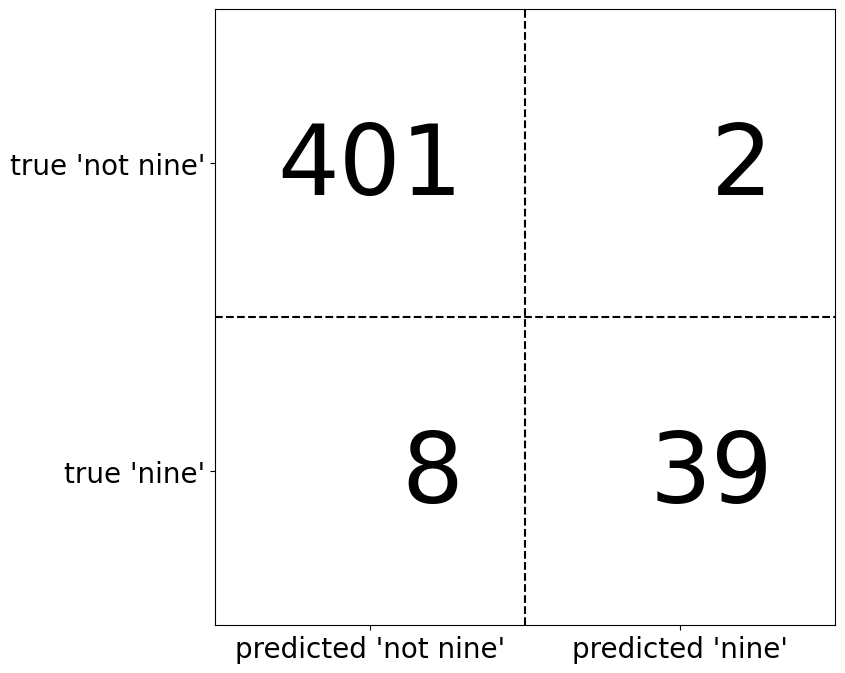

In [47]:
# illustrate what we are seeing
mglearn.plots.plot_confusion_matrix_illustration()

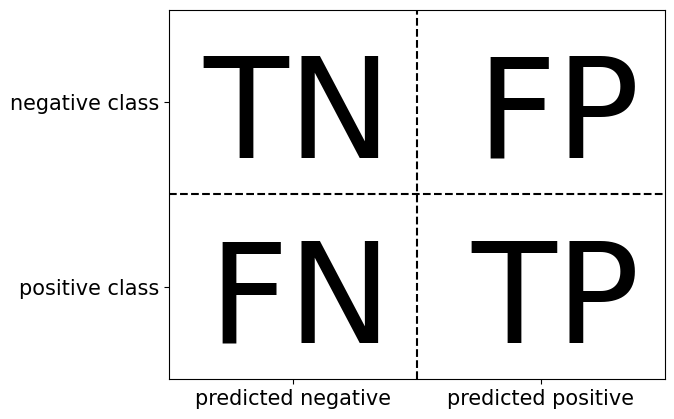

In [48]:
# in terms of error classifications
mglearn.plots.plot_binary_confusion_matrix()

In [49]:
# how did our models perform
print("Most frequent class:")
print(confusion_matrix(ytest, pred_most_frequent))
print("\nDummy model:")
print(confusion_matrix(ytest, pred_dummy))
print("\nDecision tree:")
print(confusion_matrix(ytest, pred_tree))
print("\nLogistic Regression")
print(confusion_matrix(ytest, pred_logreg))

Most frequent class:
[[403   0]
 [ 47   0]]

Dummy model:
[[403   0]
 [ 47   0]]

Decision tree:
[[390  13]
 [ 24  23]]

Logistic Regression
[[402   1]
 [  6  41]]


As a reminder, *Accuracy =*$\frac{TP+TN}{TP+TN+FP+FN}$. Other ways of evaluating a model is through *Precision =*$\frac{TP}{TP+FP}$ and *Recall =*$\frac{TP}{TP+FN}$. Precision is used when the goal is to limit the number of false positives, while Recall is used when we need to identify all the positive samples and avoid false negatives.

There is also the **f-score** or **f-measure**, which is the harmonic mean of precision and recall. *F =*$ 2 \times \frac{precision*recall}{precision+recall}$

In [50]:
from sklearn.metrics import f1_score

print("f1 score most frequent: {:.2f}".format(f1_score(ytest, pred_most_frequent)))
print("f1 score dummy: {:.2f}".format(f1_score(ytest, pred_dummy)))
print("f1 score tree: {:.2f}".format(f1_score(ytest, pred_tree)))
print("f1 score logistic regression: {:.2f}".format(f1_score(ytest, pred_logreg)))

f1 score most frequent: 0.00
f1 score dummy: 0.00
f1 score tree: 0.55
f1 score logistic regression: 0.92


In [51]:
# we can get multiple metrics at once
from sklearn.metrics import classification_report

print(classification_report(ytest, pred_most_frequent, target_names=["none nine", "nine"]))

              precision    recall  f1-score   support

   none nine       0.90      1.00      0.94       403
        nine       0.00      0.00      0.00        47

    accuracy                           0.90       450
   macro avg       0.45      0.50      0.47       450
weighted avg       0.80      0.90      0.85       450



/Users/giovannimadrigal/opt/anaconda3/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/giovannimadrigal/opt/anaconda3/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/giovannimadrigal/opt/anaconda3/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start,

In [52]:
# see other models
print(classification_report(ytest, pred_dummy, target_names=["not nine", "nine"]))
print(classification_report(ytest, pred_logreg, target_names=["not nine", "nine"]))


              precision    recall  f1-score   support

    not nine       0.90      1.00      0.94       403
        nine       0.00      0.00      0.00        47

    accuracy                           0.90       450
   macro avg       0.45      0.50      0.47       450
weighted avg       0.80      0.90      0.85       450

              precision    recall  f1-score   support

    not nine       0.99      1.00      0.99       403
        nine       0.98      0.87      0.92        47

    accuracy                           0.98       450
   macro avg       0.98      0.93      0.96       450
weighted avg       0.98      0.98      0.98       450



/Users/giovannimadrigal/opt/anaconda3/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/giovannimadrigal/opt/anaconda3/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/giovannimadrigal/opt/anaconda3/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start,

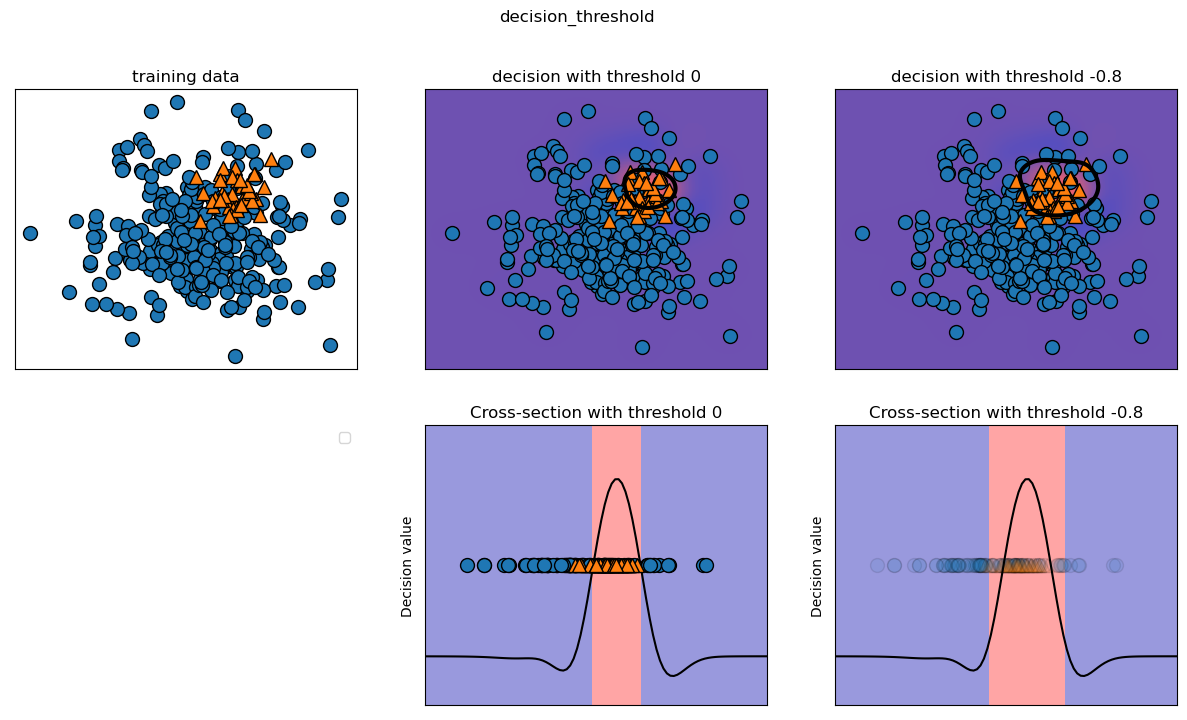

In [63]:
# we can visualize how certain each decision was made from a model
from mglearn.datasets import make_blobs

x, y = make_blobs(n_samples=(400, 50), centers=None, cluster_std=[7.0, 2], random_state=22)
xtrain, xtest, ytrain, ytest = train_test_split(x, y, random_state=0)
svc = SVC(gamma=.05).fit(xtrain, ytrain)

mglearn.plots.plot_decision_threshold()

In [ ]:
# examine the classification report
print(classification_report(ytest, svc.predict(xtest)))

#
# we will see that there is more emphasis on getting class 0 predictions right
# since there is more of it
#

              precision    recall  f1-score   support

           0       0.97      0.89      0.93       104
           1       0.35      0.67      0.46         9

    accuracy                           0.88       113
   macro avg       0.66      0.78      0.70       113
weighted avg       0.92      0.88      0.89       113



In [ ]:
# let's just the threshold
ypred_lower_threshold = svc.decision_function(xtest) > -.8
print(classification_report(ytest, ypred_lower_threshold)) # higher recall but lower precision

              precision    recall  f1-score   support

           0       1.00      0.82      0.90       104
           1       0.32      1.00      0.49         9

    accuracy                           0.83       113
   macro avg       0.66      0.91      0.69       113
weighted avg       0.95      0.83      0.87       113



A **calibrated** model is a model that provides an accurate measure of its uncertainty.

Text(0, 0.5, 'Recall')

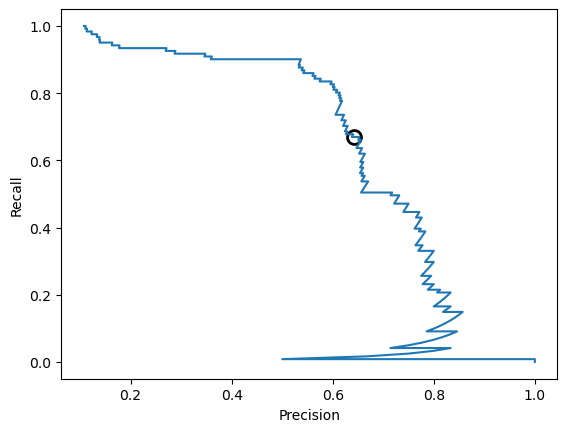

In [68]:
# we can draw a curve to to examine the precision & recall tradeoffs
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(ytest, svc.decision_function(xtest))

# add more points for a smoother curve
x, y = make_blobs(n_samples=(4000, 500), centers=None, cluster_std=[7.0, 2], random_state=22)
xtrain, xtest, ytrain, ytest = train_test_split(x, y, random_state=0)
svc = SVC(gamma=.05).fit(xtrain, ytrain)
precision, recall, thresholds = precision_recall_curve(ytest, svc.decision_function(xtest))
# find threshold closest to zero
close_zero = np.argmin(np.abs(thresholds))

plt.plot(precision[close_zero], recall[close_zero], 'o', markersize=10, label="threshold zero", fillstyle="none", c='k', mew=2)
plt.plot(precision, recall, label="precision recall curve")
plt.xlabel("Precision")
plt.ylabel("Recall")

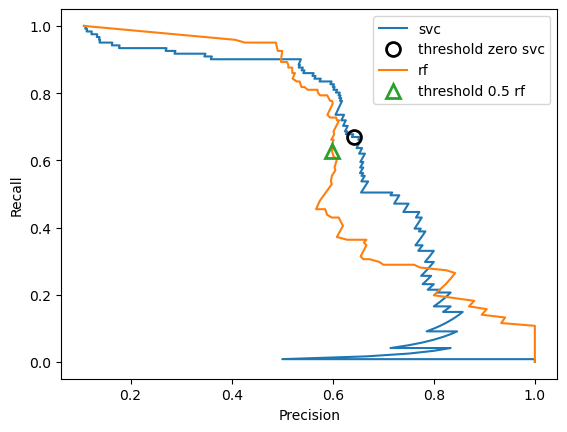

In [69]:
# look at the tradeoffs when the classifier is a random forest
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=0, max_features=2)
rf.fit(xtrain, ytrain)

# RandomForestClassifier has predict_proba, but not decision_function
precision_rf, recall_rf, thresholds_rf = precision_recall_curve(ytest, rf.predict_proba(xtest)[:, 1])

plt.plot(precision, recall, label="svc")
plt.plot(precision[close_zero], recall[close_zero], 'o', markersize=10,
label="threshold zero svc", fillstyle="none", c='k', mew=2)
plt.plot(precision_rf, recall_rf, label="rf")
close_default_rf = np.argmin(np.abs(thresholds_rf - 0.5))
plt.plot(precision_rf[close_default_rf], recall_rf[close_default_rf], '^', markersize=10, label="threshold 0.5 rf", fillstyle="none", mew=2)
plt.xlabel("Precision")
plt.ylabel("Recall")
plt.legend(loc="best")

This is more helpful than looking at the f1-score, which can be misleading because it is only captures one point on the precision-recall curve, the one given by the default threshold

In [70]:
print("f1_score of random forest: {:.3f}".format(f1_score(ytest, rf.predict(xtest))))
print("f1_score of svc: {:.3f}".format(f1_score(ytest, svc.predict(xtest))))

f1_score of random forest: 0.610
f1_score of svc: 0.656


One particular way to summarize the precesion-recall curve is by computing the integral or area under the curve of the precision-recall curve, also known as **average precision**.

In [71]:
from sklearn.metrics import average_precision_score

ap_rf  = average_precision_score(ytest, rf.predict_proba(xtest)[:,1])
ap_svc = average_precision_score(ytest, svc.decision_function(xtest))
print(ap_rf)
print(ap_svc)

0.659559370099291
0.6663140319391998


There is another tool that is commonly used to analyze the behavior of classifiers at different thresholds: the **receiver operating characteristics curve (ROC curve)**. The ROC curve considers all possible thresholds for a given classifier and shows the false positive rate against the true positive rate. As a reminder, *FPR =*$\frac{FP}{FP+TN}$.

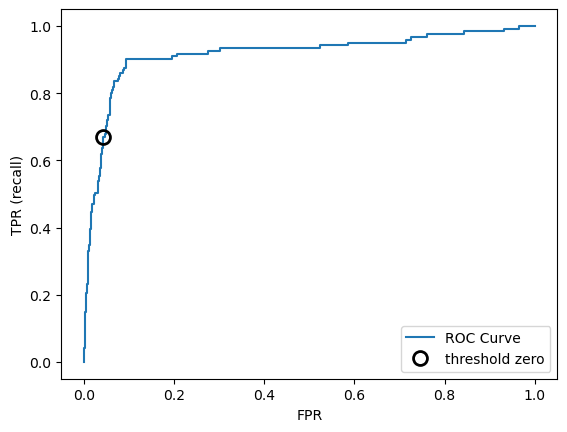

In [72]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(ytest, svc.decision_function(xtest))

plt.plot(fpr, tpr, label="ROC Curve")
plt.xlabel("FPR")
plt.ylabel("TPR (recall)")
# find threshold closest to zero
close_zero = np.argmin(np.abs(thresholds))
plt.plot(fpr[close_zero], tpr[close_zero], 'o', markersize=10, label="threshold zero", fillstyle="none", c='k', mew=2)
plt.legend(loc=4)


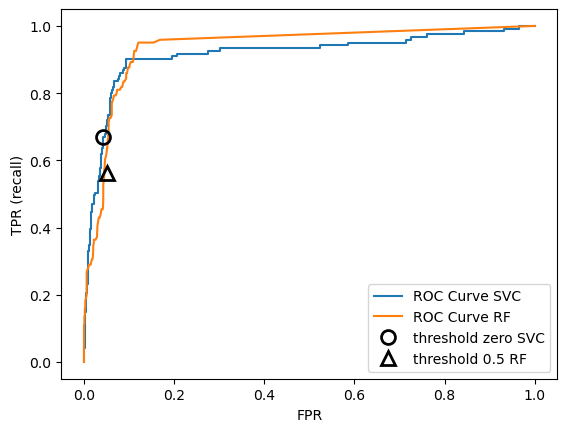

In [73]:
# how does this fair against the random forest model

fpr_rf, tpr_rf, thresholds_rf = roc_curve(ytest, rf.predict_proba(xtest)[:, 1])

plt.plot(fpr, tpr, label="ROC Curve SVC")
plt.plot(fpr_rf, tpr_rf, label="ROC Curve RF")
plt.xlabel("FPR")
plt.ylabel("TPR (recall)")
plt.plot(fpr[close_zero], tpr[close_zero], 'o', markersize=10,
label="threshold zero SVC", fillstyle="none", c='k', mew=2)
close_default_rf = np.argmin(np.abs(thresholds_rf - 0.5))
plt.plot(fpr_rf[close_default_rf], tpr[close_default_rf], '^', markersize=10, label="threshold 0.5 RF", fillstyle="none", c='k', mew=2)
plt.legend(loc=4)

In [74]:
#
# Compute the Area Under the Curve (AUC)
#
from sklearn.metrics import roc_auc_score

rf_auc  = roc_auc_score(ytest, rf.predict_proba(xtest)[:, 1])
svc_auc = roc_auc_score(ytest, svc.decision_function(xtest))
print("AUC for Random Forest: {:.3f}".format(rf_auc))
print("AUC for SVC: {:.3f}".format(svc_auc))

AUC for Random Forest: 0.937
AUC for SVC: 0.916


AUC measures a model's overall ability to separate positive and negative classes across all possible classification thresholds, making it more reliable than accuracy in these cases

gamma = 1.00 accuracy = 0.90 AUC = 0.50
gamma = 0.05 accuracy = 0.90 AUC = 1.00
gamma = 0.01 accuracy = 0.90 AUC = 1.00


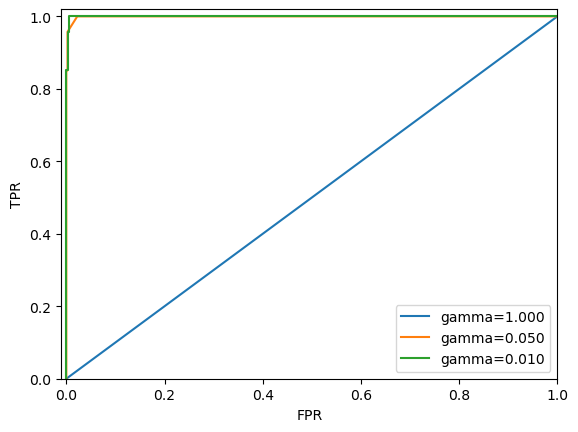

In [75]:
# visualize AUC with an imbalanced dataset
y = digits.target == 9
xtrain, xtest, ytrain, ytest = train_test_split(digits.data, y, random_state=0)

plt.figure()
for gamma in [1, 0.05, 0.01]:
    svc         = SVC(gamma=gamma).fit(xtrain, ytrain)
    accuracy    = svc.score(xtest, ytest)
    auc         = roc_auc_score(ytest, svc.decision_function(xtest))
    fpr, tpr, _ = roc_curve(ytest , svc.decision_function(xtest))
    print("gamma = {:.2f} accuracy = {:.2f} AUC = {:.2f}".format(gamma, accuracy, auc))
    plt.plot(fpr, tpr, label="gamma={:.3f}".format(gamma))

plt.xlabel("FPR")
plt.ylabel("TPR")
plt.xlim(-0.01, 1)
plt.ylim(0, 1.02)
plt.legend(loc="best")

## Metrics for Multiclass Classification

In [76]:
from sklearn.metrics import accuracy_score

xtrain, xtest, ytrain, ytest = train_test_split(digits.data, digits.target, random_state=0)
lr   = LogisticRegression().fit(xtrain, ytrain)
pred = lr.predict(xtest)
print(accuracy_score(ytest, pred))
print(confusion_matrix(ytest, pred))

0.9511111111111111
[[37  0  0  0  0  0  0  0  0  0]
 [ 0 40  0  0  0  0  0  0  2  1]
 [ 0  1 40  3  0  0  0  0  0  0]
 [ 0  0  0 43  0  0  0  0  1  1]
 [ 0  0  0  0 37  0  0  1  0  0]
 [ 0  0  0  0  0 46  0  0  0  2]
 [ 0  1  0  0  0  0 51  0  0  0]
 [ 0  0  0  1  1  0  0 46  0  0]
 [ 0  3  1  0  0  0  0  0 43  1]
 [ 0  0  0  0  0  1  0  0  1 45]]


/Users/giovannimadrigal/opt/anaconda3/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:444: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


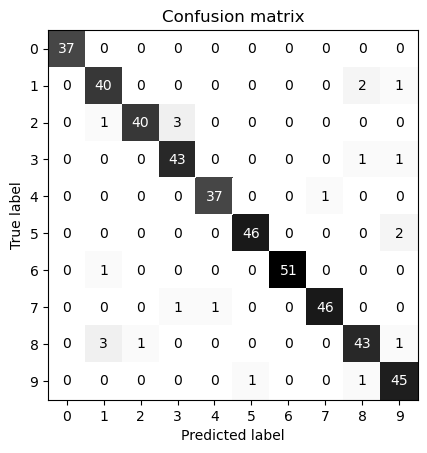

In [77]:
# visualize the confusion matrix
scores_image = mglearn.tools.heatmap(confusion_matrix(ytest, pred), xlabel='Predicted label', ylabel='True label', xticklabels=digits.target_names, yticklabels=digits.target_names, cmap=plt.cm.gray_r, fmt="%d")
plt.title("Confusion matrix")
plt.gca().invert_yaxis()

In [78]:
# get the metrics
print(classification_report(ytest, pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        37
           1       0.89      0.93      0.91        43
           2       0.98      0.91      0.94        44
           3       0.91      0.96      0.93        45
           4       0.97      0.97      0.97        38
           5       0.98      0.96      0.97        48
           6       1.00      0.98      0.99        52
           7       0.98      0.96      0.97        48
           8       0.91      0.90      0.91        48
           9       0.90      0.96      0.93        47

    accuracy                           0.95       450
   macro avg       0.95      0.95      0.95       450
weighted avg       0.95      0.95      0.95       450



In the above
- The *macro* averaging computes the unweighted per-class f-scores. This gives equal weight to all classes, no matter what their size/proportion is.
- The *weighted* averaging computes the mean of the per-class f-scores, weighted by their support. This is what is reported in the classification report.
- *micro* averaging computes the total number of false positives, false negatives, and true positives over all classes, and then computes precision, recall, and f-score using these counts

If you are about each *sample* equally much, it is recommended to use *micro*. If you care about each *class* equally much, it is recommended to use *macro*.

In [79]:
print("Micro average f1 score: {:.3f}".format(f1_score(ytest, pred, average="micro")))
print("Macro average f1 score: {:.3f}".format(f1_score(ytest, pred, average="macro")))

Micro average f1 score: 0.951
Macro average f1 score: 0.952


In [ ]:
# below, we ill illustrate what we have covered by
# constructing a svm, using cross validation, and evaluating via AUC

# default scoring for classification is accuracy
print("Default scoring: {}".format(cross_val_score(SVC(), digits.data, digits.target == 9)))
# providing scoring="accuracy" doesn't change the results
explicit_accuracy = cross_val_score(SVC(), digits.data, digits.target == 9, scoring="accuracy")
print("Explicit accuracy scoring: {}".format(explicit_accuracy))
roc_auc = cross_val_score(SVC(), digits.data, digits.target == 9, scoring="roc_auc")
print("AUC scoring: {}".format(roc_auc))

Default scoring: [0.975      0.99166667 1.         0.99442897 0.98050139]
Explicit accuracy scoring: [0.975      0.99166667 1.         0.99442897 0.98050139]
AUC scoring: [0.99717078 0.99854252 1.         0.999828   0.98400413]


In [81]:
# using grid search instead
xtrain, xtest, ytrain, ytest = train_test_split(digits.data, digits.target == 9, random_state=0)

# we provide a somewhat bad grid to illustrate the point:
param_grid = {'gamma': [0.0001, 0.01, 0.1, 1, 10]}
# using the default scoring of accuracy:
grid = GridSearchCV(SVC(), param_grid=param_grid)
grid.fit(xtrain, ytrain)

print("Grid-Search with accuracy")
print("Best parameters:", grid.best_params_)
print("Best cross-validation score (accuracy)): {:.3f}".format(grid.best_score_))
print("Test set AUC: {:.3f}".format(roc_auc_score(ytest, grid.decision_function(xtest))))
print("Test set accuracy: {:.3f}".format(grid.score(xtest, ytest)))

Grid-Search with accuracy
Best parameters: {'gamma': 0.0001}
Best cross-validation score (accuracy)): 0.976
Test set AUC: 0.992
Test set accuracy: 0.973


In [82]:
# using AUC scoring instead:
grid = GridSearchCV(SVC(), param_grid=param_grid, scoring="roc_auc")
grid.fit(xtrain, ytrain)
print("\nGrid-Search with AUC")
print("Best parameters:", grid.best_params_)
print("Best cross-validation score (AUC): {:.3f}".format(grid.best_score_))
print("Test set AUC: {:.3f}".format(
roc_auc_score(ytest, grid.decision_function(xtest))))
print("Test set accuracy: {:.3f}".format(grid.score(xtest, ytest)))


Grid-Search with AUC
Best parameters: {'gamma': 0.01}
Best cross-validation score (AUC): 0.998
Test set AUC: 1.000
Test set accuracy: 1.000


In [83]:
# full list of ways to get metrics for evaluation for your models
from sklearn.metrics._scorer import SCORERS
print(SCORERS.keys())

dict_keys(['explained_variance', 'r2', 'max_error', 'matthews_corrcoef', 'neg_median_absolute_error', 'neg_mean_absolute_error', 'neg_mean_absolute_percentage_error', 'neg_mean_squared_error', 'neg_mean_squared_log_error', 'neg_root_mean_squared_error', 'neg_mean_poisson_deviance', 'neg_mean_gamma_deviance', 'accuracy', 'top_k_accuracy', 'roc_auc', 'roc_auc_ovr', 'roc_auc_ovo', 'roc_auc_ovr_weighted', 'roc_auc_ovo_weighted', 'balanced_accuracy', 'average_precision', 'neg_log_loss', 'neg_brier_score', 'adjusted_rand_score', 'rand_score', 'homogeneity_score', 'completeness_score', 'v_measure_score', 'mutual_info_score', 'adjusted_mutual_info_score', 'normalized_mutual_info_score', 'fowlkes_mallows_score', 'precision', 'precision_macro', 'precision_micro', 'precision_samples', 'precision_weighted', 'recall', 'recall_macro', 'recall_micro', 'recall_samples', 'recall_weighted', 'f1', 'f1_macro', 'f1_micro', 'f1_samples', 'f1_weighted', 'jaccard', 'jaccard_macro', 'jaccard_micro', 'jaccard_s